# **Laboratorio 6: Una introducción al algoritmo de Descenso de Gradiente**
**Facultad de ingeniería**

Departamento de Ingeniería Biomédica

Universidad de los Andes

**IBIO-2440** Fundamentos de Machine Learning

**Nombres de los integrantes**


1.   Nombre integrante 1
2.   Nombre integrante 2
3.   Nombre integrante 3

**Número del grupo**

*Escribir el número del grupo*


# **Descenso de Gradiente**

Gradient Descent en inglés o simplemente GD, se trata de un algoritmo de optimización de primer orden con la capacidad de hallar valores mínimos en una amplia gama de problemas de optimización libre (sin restricciones).

**1. Fundamento teórico**

El concepto fundamental que soporta el funcionamiento del algoritmo es el de *gradiente de una función* $\nabla_{f}$. Recordemos de Calculo Vectorial que el gradiente $\nabla_{f}$ de una función $f: \mathbb{R^n} \rightarrow \mathbb{R}$ diferenciable se trata de un vector n-dimensional que apunta en la dirección que máximiza el cambio, la dirección de máximo crecimiento de la función, perpendicular a las curvas de nivel y cuya magnitud representa la pendiente entre dos curvas de nivel en la dirección de máximo crecimiento (es mayor conforme más cerca entre sí estan las curvas de nivel es decir, entre mayor es el cambio de altura entre dos puntos). Bajo estas propiedades, si recorremos la función desde un punto arbitrario en su dominio siguiendo la dirección del gradiente, vamos a construir el camino más corto que conduce al valor máximo de la función.

**2. Algoritmo de Descenso de Gradiente**

A partir de estas propiedades del gradiente, el algoritmo de Descenso de Gradiente propone hallar el mínimo de una función $f: \mathbb{R^n} \rightarrow \mathbb{R}$ diferenciable, recorriendo la función en la dirección opuesta a la que apunta el gradiente (es decir, la dirección de mínimo crecimiento), de esta forma podemos construir un camino, el más corto, que conduce al valor mínimo de la función:

\begin{align*}
x_{n+1} = x_{n} - \nabla_f(x_{n})
\end{align*}

Este algoritmo nos conduce inevitablemente al mínimo de la función. No obstante, dependiendo el comportamiento de la función, el gradiente puede ser inestable (variar de valores muy grandes a muy pequeños) lo que dificulta al algoritmo converger de forma eficiente al mínimo. Por esta razón resulta conveniente agregar un factor que escale el valor del gradiente y que permita controlar la longitud en cada paso del recorrido:

\begin{align*}
x_{n+1} = x_{n} - \alpha \nabla_f(x_{n})
\end{align*}

El factor $\alpha$ es un número real positivo que se conoce como *tasa de aprendizaje (learning rate en inglés)* y es un hiperparámetro crítico en el algoritmo, puesto que determina su velocidad de convergencia, la estabilidad del proceso y puede afectar el valor mínimo hallado.

Veamos paso a paso como opera el algoritmo:

1. **Iniciamos desde un punto de partida ($x_0$)**: Este punto inicial es arbitrario, un punto cualquiera en el dominio de la función. Su elección se hace crítica cuando la función no es convexa o tiene varios mínimos locales.

2. **Calculamos el gradiente en este punto $\nabla_f(x_{0})$**: Calculamos el vector gradiente de la función objetivo $\nabla_{f}$ y lo evaluamos en el punto de partida $\nabla_{f}(x_{0})$. 

3. **Elegimos una tasa de aprendizaje adecuada ($\alpha$)**: Su valor es muy crítico: un valor de $\alpha$ muy pequeño implica una convergencia muy lenta, por otro lado, un valor de $\alpha$ muy grande podría saltar muchos detalles de la geometría de la función y nos haría perder el rumbo o incluso pasar por encima del mínimo, haciendo que el algoritmo nunca converja.

4. **Hallamos un nuevo punto inicial ($x_1$)**: Al tomar la diferencia $x_0 - \alpha \nabla_{f}(x_{0})$ damos un paso en dirección al mínimo que nos lleva a un nuevo punto $x_1$ que se encuentra más cerca de éste valor:

\begin{align*}
x_{1} = x_{0} - \alpha \nabla_f(x_{0})
\end{align*}

5. **Iteramos**: Tomando $x_{1}$ como nuevo punto inicial repetimos el proceso anterior, que continua siguiendo el algoritmo:

\begin{align*}
x_{n+1} = x_{n} - \alpha \nabla_f(x_{n})
\end{align*}

Hasta que se observa que la variación entre cada punto nuevo se encuentra por debajo de una tolerancia definida, allí el método finaliza y tomamos el último valor $x_{n+1}$ como el mínimo de la función.


A continuación se presenta un pseudoalgoritmo para el método de Descenso de Gradiente, donde $x[k]$ es un vector en $R^n$ que corresponde al resultado de la iteración $k$, $\nabla_f$ es el gradiente de la función y $\alpha$ es la tasa de aprendizaje.

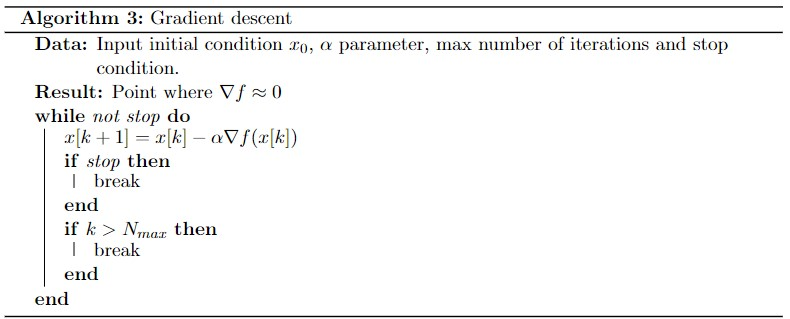

**1.1 Ejercicios**


- Se requiere resolver el siguiente problema de optimización libre:


  $$\min_x f(\mathbf{x}) = \frac{1}{2}\mathbf{x}^TQ\mathbf{x}+B^T\mathbf{x}+C,   
  x \in R^2$$



- Donde:

$$
  Q = \begin{pmatrix}
  1 & 3 \\
  -2 & 1
  \end{pmatrix},
$$
$$
  B = \begin{pmatrix}
  1/2 \\
  1
  \end{pmatrix},
$$
$$
  C= 5,
$$
$$
  x= [x_1, x_2]^T
$$

1. ¿Cúal es la finalidad de encontrar un punto donde el gradiente de una función objetivo se anule en un contexto de optimización?

2. Determine de forma **analítica** si el problema es convexo o no, en caso de serlo, calcule **analíticamente** el minimizador.

3. Implemente una función que reciba como argumento un punto $[x_1, x_2]^T$ y retorne el vector gradiente evaluado en ese punto, para ello calcule teóricamente el gradiente de la forma cuadrática y agreguelo en la implementación. **Nota:** No puede usar librerias de cálculo simbólico.

4. Implemente una función que reciba como argumento un punto inicial $X_0$, un parámetro $\alpha > 0$ , un número máximo de pasos $N$ y un parámetro $\epsilon > 0$ que defina la tolerancia. Utilice como criterio de parada la expresión  $||x[k+1]-x[k]||_2 \leq ϵ$, así el algoritmo de Descenso de Gradiente converge si $x[k+1]$ es muy cercano a $x[k]$. La función debe retornar un diccionario con 4 elementos: el historial de los puntos por donde pasa el algoritmo (es decir, todos sus puntos $x[k]$), la función evaluada en cada punto $f(x[k])$, el punto $x_k$ que corresponde al valor mínimo y un booleano que indique si se superó el número máximo de pasos permitido (*True* si se superan los pasos, *False* en caso contrario).  

5. Implemente una función con la misma estructura de la función del punto anterior pero que tome como criterio de parada $||∇f(x[k])||_2≤\epsilon$, es decir, el algoritmo se debe detener si la norma del gradiente es menor a la tolerancia definida. ¿Que implicaciones tiene esta nueva condición en el funcionamiento del algoritmo respecto a la condición del ejercicio anterior?

6. Evalúe las funciones implementadas en los ejercicios 4 y 5 para calcular el posible minimizador local de la forma cuadrática suministrada considerando los siguientes parámetros:

  - $\epsilon = 0.1$
  - $n = 100$
  - $X_0 = [2,2]^T$

  Además, ambas funciones deben ser invocadas para tres valores distintos de la tasa de aprendizaje, $\alpha = [0.1, 0.5, 0.8]$

7. En un figura de 2 columnas y 3 filas grafique las curvas de nivel de la forma cuadrática y las trayectorias de búsqueda del mínimizador que obtuvo como resultado en el punto anterior, para cada una de las tasas de aprendizaje. Agregue un título relacionado así como etiquetas en los ejes.

  **Hint:** Cada uno de sus subplots debería lucir *similar* al que se presenta a continuación:

  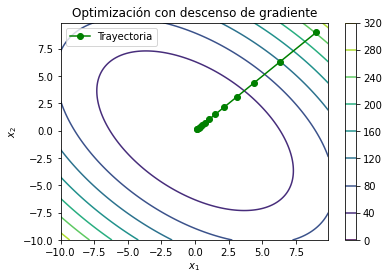

8. Responda las siguientes preguntas:


  - ¿Que valor de $\alpha$ considera que fue el mejor? ¿Por qué?

  - ¿Por qué cree que un valor de $\alpha$ muy grande no permite alcanzar la convergencia?

  - ¿Qué condición de parada entre las dos que se implementaron considera que es mejor en este caso? ¿Por qué?

  - ¿Qué pasaría si se usa el algoritmo de Descenso de Gradiente con una forma cuadrática no convexa?